Smart Waste Classification Using Deep Learning and Explainable AI

Plastic bottle

       ↓
MobileNetV2

       ↓
Prediction

       ↓
Plastic

       ↓
Confidence: 94.7%

       ↓
Grad-CAM

       ↓
Highlighted important region

Classes

1. Cardboard
2. Glass
3. Metal
4. Paper
5. Plastic
6. Trash

Step 1 — Mount Google Drive

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Step 2 — Check Dataset ZIP

Change only the filename if your downloaded ZIP has a different name.

In [2]:
import os

ZIP_PATH = "/content/drive/MyDrive/Garbage_Dataset.zip"

print("ZIP exists:", os.path.exists(ZIP_PATH))
print("ZIP path:", ZIP_PATH)

ZIP exists: True
ZIP path: /content/drive/MyDrive/Garbage_Dataset.zip


Step 3 — Extract Dataset

In [3]:
import zipfile
import os

EXTRACT_PATH = "/content/waste_dataset"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully!")

Dataset extracted successfully!


Step 4 — Automatically Find Dataset Folder

Again, we're going to automatically detect the folder rather than guessing paths.

In [4]:
print("Searching for dataset folders...\n")

for root, dirs, files in os.walk(EXTRACT_PATH):

    level = root.replace(EXTRACT_PATH, "").count(os.sep)

    if level <= 2:
        print(root, "→", len(files), "files")

Searching for dataset folders...

/content/waste_dataset → 0 files
/content/waste_dataset/garbage_classification → 0 files
/content/waste_dataset/garbage_classification/trash → 697 files
/content/waste_dataset/garbage_classification/paper → 1050 files
/content/waste_dataset/garbage_classification/clothes → 5325 files
/content/waste_dataset/garbage_classification/white-glass → 775 files
/content/waste_dataset/garbage_classification/cardboard → 891 files
/content/waste_dataset/garbage_classification/plastic → 865 files
/content/waste_dataset/garbage_classification/green-glass → 629 files
/content/waste_dataset/garbage_classification/brown-glass → 607 files
/content/waste_dataset/garbage_classification/biological → 985 files
/content/waste_dataset/garbage_classification/battery → 945 files
/content/waste_dataset/garbage_classification/metal → 769 files
/content/waste_dataset/garbage_classification/shoes → 1977 files


Dataset

   ↓

EDA / Visualization

   ↓

Data Augmentation

   ↓

MobileNetV2

   ↓

Transfer Learning

   ↓

Dropout + L2

   ↓

Early Stopping

   ↓

Training

   ↓

Accuracy/Loss

   ↓

Confusion Matrix

   ↓

Classification Report

   ↓

Image Prediction

   ↓

Grad-CAM

   ↓

Flask

   ↓

ngrok

   ↓
   
♻️ Smart Waste AI

Step 5 — Load Waste Dataset

In [5]:
import tensorflow as tf

WASTE_DATASET_PATH = "/content/waste_dataset/garbage_classification"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    WASTE_DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    WASTE_DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

waste_class_names = train_ds.class_names

print("\n================================")
print("WASTE DATASET")
print("================================")

print("Number of classes:", len(waste_class_names))

print("\nClasses:")

for i, name in enumerate(waste_class_names):
    print(i, "→", name)

Found 15515 files belonging to 12 classes.
Using 12412 files for training.
Found 15515 files belonging to 12 classes.
Using 3103 files for validation.

WASTE DATASET
Number of classes: 12

Classes:
0 → battery
1 → biological
2 → brown-glass
3 → cardboard
4 → clothes
5 → green-glass
6 → metal
7 → paper
8 → plastic
9 → shoes
10 → trash
11 → white-glass


Step 6 — Visualize Waste Images

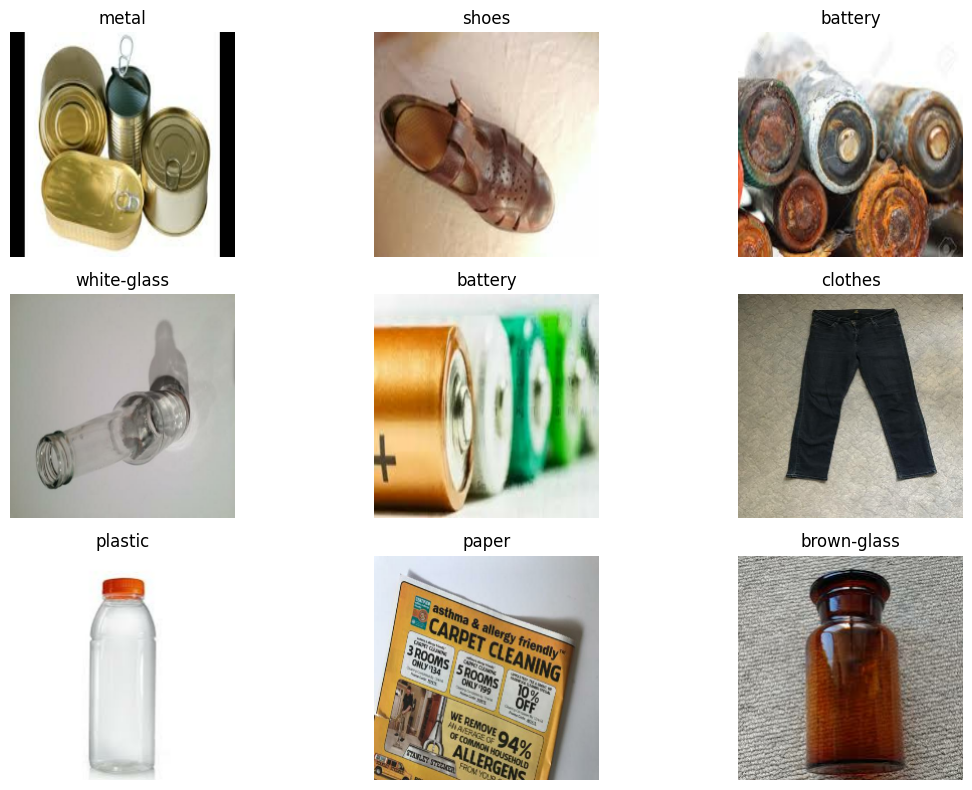

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            waste_class_names[labels[i]]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

Step 7 — Data Augmentation

We'll reuse the Day 4 techniques:

In [7]:
waste_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.1)
])

print("Waste data augmentation pipeline created successfully!")

Waste data augmentation pipeline created successfully!


Step 8 — Visualize Augmentation

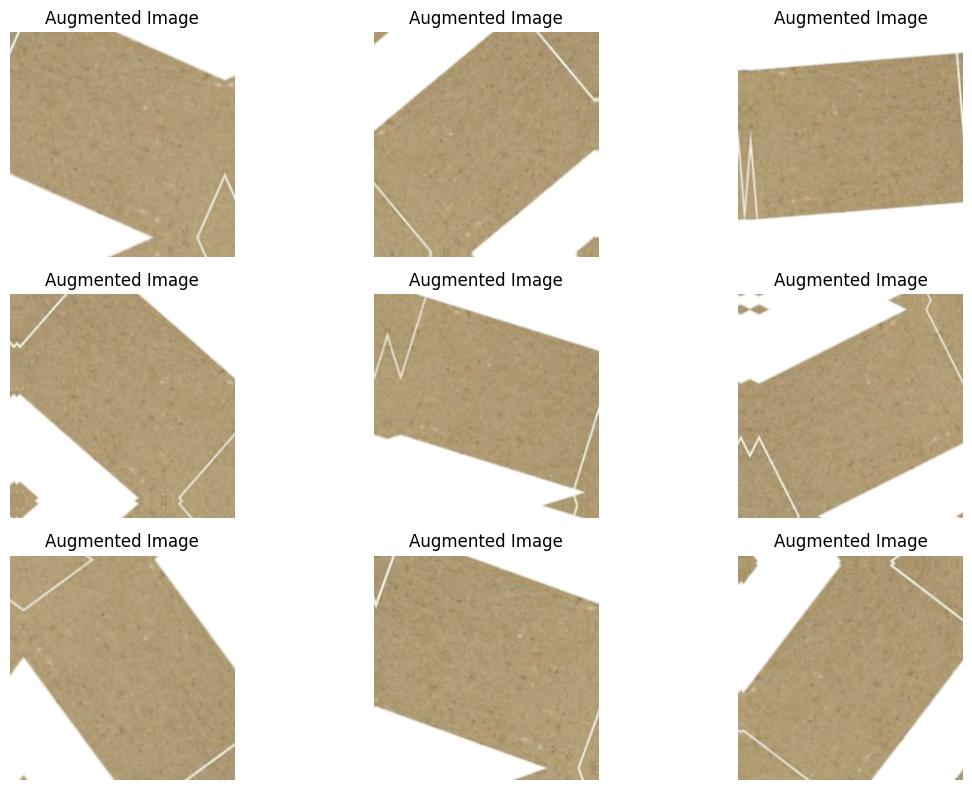

In [8]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    original_image = images[0]

    for i in range(9):

        augmented_image = waste_augmentation(
            tf.expand_dims(
                original_image,
                axis=0
            ),
            training=True
        )[0]

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            tf.cast(
                tf.clip_by_value(
                    augmented_image,
                    0,
                    255
                ),
                tf.uint8
            )
        )

        plt.title("Augmented Image")
        plt.axis("off")

plt.tight_layout()
plt.show()

Step 9 — Optimize Dataset

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

print("Waste dataset pipeline optimized!")

Waste dataset pipeline optimized!


Step 10 — MobileNetV2

Now we build the same transfer-learning architecture that worked successfully in Project 1.

In [10]:
from tensorflow.keras.applications import MobileNetV2

waste_base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

waste_base_model.trainable = False

print("MobileNetV2 loaded successfully!")
print("Total layers:", len(waste_base_model.layers))
print("Trainable:", waste_base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 loaded successfully!
Total layers: 154
Trainable: False


Step 11 — Build Waste Classification Model

In [11]:
from tensorflow.keras import layers, models, regularizers

waste_inputs = layers.Input(
    shape=(224, 224, 3)
)

# Data Augmentation
x = waste_augmentation(waste_inputs)

# MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Pretrained MobileNetV2
x = waste_base_model(
    x,
    training=False
)

# Feature extraction
x = layers.GlobalAveragePooling2D()(x)

# Dropout
x = layers.Dropout(0.30)(x)

# Dense + L2 Regularization
x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(x)

# Dropout
x = layers.Dropout(0.20)(x)

# Final 12-class output
waste_outputs = layers.Dense(
    len(waste_class_names),
    activation="softmax"
)(x)

waste_model = models.Model(
    waste_inputs,
    waste_outputs
)

waste_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,500 (9.24 MB)

 Trainable params: 165,516 (646.55 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

224×224×3

     ↓

Data Augmentation

     ↓

MobileNetV2

     ↓

Global Average Pooling

     ↓

Dropout 30%

     ↓

Dense 128 + ReLU + L2

     ↓

Dropout 20%

     ↓
     
Dense 12 + Softmax

Step 12 — Compile

In [12]:
waste_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Waste classification model compiled successfully!")

Waste classification model compiled successfully!


Step 13 — Early Stopping

In [13]:
waste_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Early stopping configured!")

Early stopping configured!


Step 14 — Train

In [14]:
waste_history = waste_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[waste_early_stopping]
)

Epoch 1/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 40s 82ms/step - accuracy: 0.5906 - loss: 1.5858 - val_accuracy: 0.8666 - val_loss: 0.7677
Epoch 2/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.7967 - loss: 0.8851 - val_accuracy: 0.9036 - val_loss: 0.5750
Epoch 3/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.8348 - loss: 0.7411 - val_accuracy: 0.9152 - val_loss: 0.5095
Epoch 4/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.8514 - loss: 0.6916 - val_accuracy: 0.9220 - val_loss: 0.4785
Epoch 5/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 29s 76ms/step - accuracy: 0.8709 - loss: 0.6329 - val_accuracy: 0.9288 - val_loss: 0.4502
Epoch 6/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.8744 - loss: 0.6087 - val_accuracy: 0.9323 - val_loss: 0.4387
Epoch 7/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 29s 76ms/step - accuracy: 0.8830 - loss: 0.5746 - val_accuracy: 0.9307 - val_loss: 0.4261
Epoch 8/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.8862 - loss: 0.5617 - 

Step 15 — Plot Training Accuracy

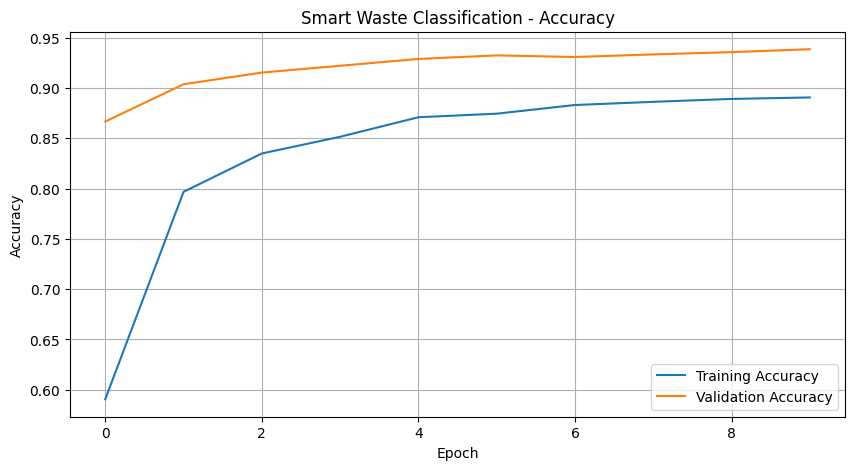

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    waste_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    waste_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Smart Waste Classification - Accuracy")

plt.legend()
plt.grid(True)

plt.show()

Step 16 — Plot Training Loss

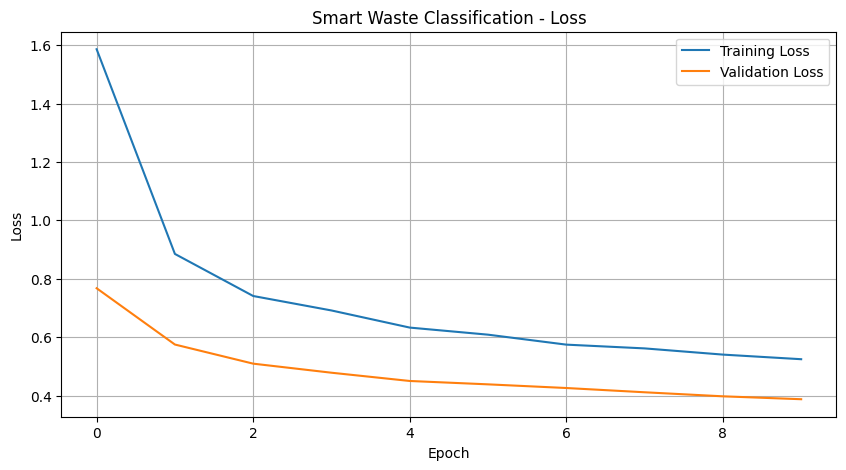

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    waste_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    waste_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Smart Waste Classification - Loss")

plt.legend()
plt.grid(True)

plt.show()

Step 17 — Final Model Evaluation

In [17]:
waste_val_loss, waste_val_accuracy = waste_model.evaluate(
    val_ds,
    verbose=1
)

print("\n======================================")
print("SMART WASTE MODEL PERFORMANCE")
print("======================================")

print(f"Validation Loss     : {waste_val_loss:.4f}")
print(f"Validation Accuracy : {waste_val_accuracy * 100:.2f}%")

97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.9384 - loss: 0.3878

SMART WASTE MODEL PERFORMANCE
Validation Loss     : 0.3878
Validation Accuracy : 93.84%


Step 18 — Generate Validation Predictions

In [18]:
import numpy as np

waste_y_true = []
waste_y_pred = []

for images, labels in val_ds:

    predictions = waste_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    waste_y_true.extend(
        labels.numpy()
    )

    waste_y_pred.extend(
        predicted_classes
    )

waste_y_true = np.array(waste_y_true)
waste_y_pred = np.array(waste_y_pred)

print("Prediction completed!")
print(
    "Validation samples:",
    len(waste_y_true)
)

Prediction completed!
Validation samples: 3103


Step 19 — Classification Report

In [19]:
from sklearn.metrics import classification_report

print(
    classification_report(
        waste_y_true,
        waste_y_pred,
        target_names=waste_class_names
    )
)

              precision    recall  f1-score   support

     battery       0.96      0.96      0.96       180
  biological       0.99      0.97      0.98       195
 brown-glass       0.91      0.88      0.89       111
   cardboard       0.92      0.90      0.91       176
     clothes       0.98      0.99      0.98      1065
 green-glass       0.90      0.89      0.90       122
       metal       0.75      0.92      0.82       145
       paper       0.96      0.89      0.92       218
     plastic       0.83      0.84      0.84       189
       shoes       0.95      0.99      0.97       407
       trash       0.96      0.90      0.93       143
 white-glass       0.90      0.74      0.82       152

    accuracy                           0.94      3103
   macro avg       0.92      0.91      0.91      3103
weighted avg       0.94      0.94      0.94      3103



Step 20 — Confusion Matrix

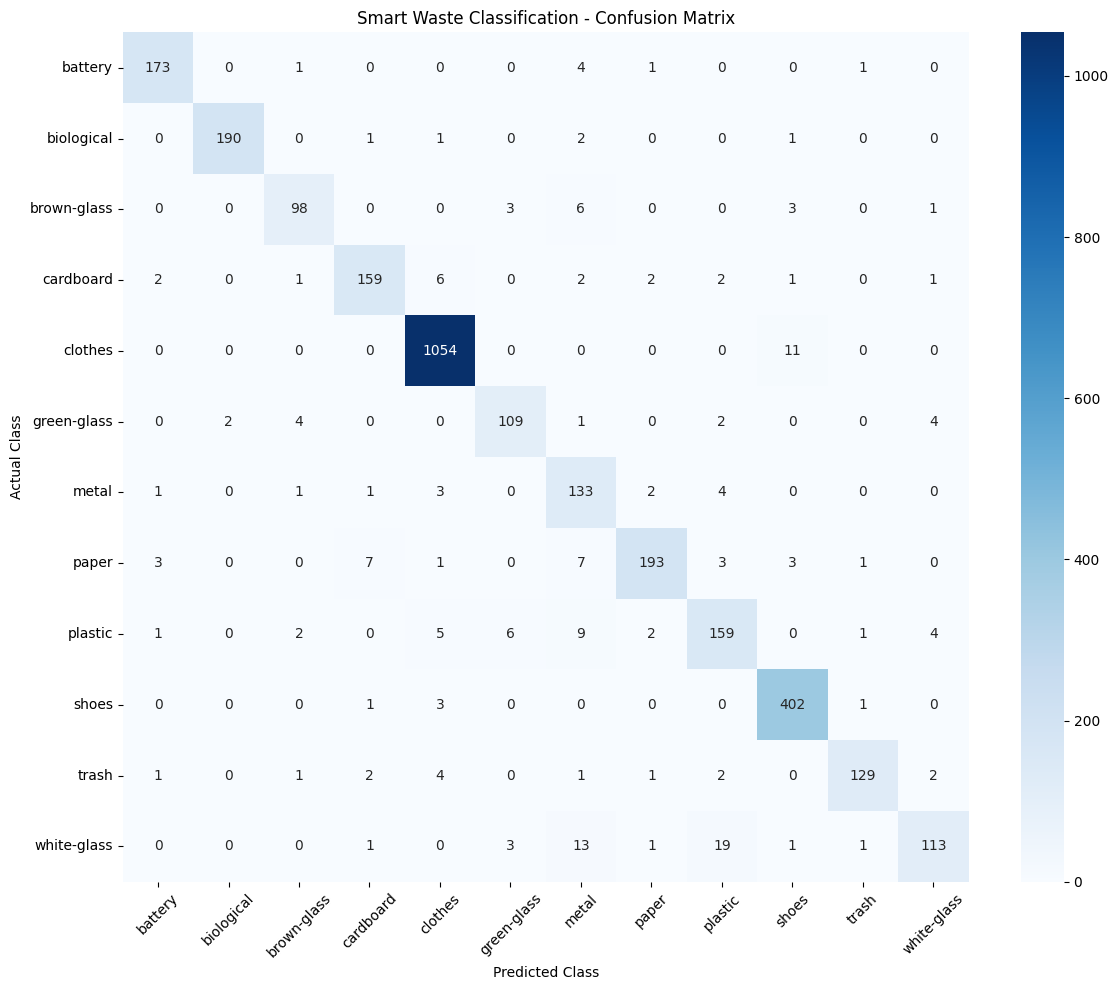

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

waste_cm = confusion_matrix(
    waste_y_true,
    waste_y_pred
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    waste_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=waste_class_names,
    yticklabels=waste_class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Smart Waste Classification - Confusion Matrix"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Step 21 — Save the Trained Model

In [22]:
WASTE_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "smart_waste_mobilenetv2.keras"
)

waste_model.save(WASTE_MODEL_PATH)

print("====================================")
print("MODEL SAVED SUCCESSFULLY")
print("====================================")
print(WASTE_MODEL_PATH)

MODEL SAVED SUCCESSFULLY
/content/drive/MyDrive/smart_waste_mobilenetv2.keras


Step 22 — Test One Waste Image

Now let's test an individual image.

In [23]:
import random
import os

random_class = random.choice(
    waste_class_names
)

class_path = os.path.join(
    WASTE_DATASET_PATH,
    random_class
)

image_files = [
    f for f in os.listdir(class_path)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
]

random_image = random.choice(
    image_files
)

waste_image_path = os.path.join(
    class_path,
    random_image
)

print("Actual Class:", random_class)
print("Image:", random_image)
print("Path:", waste_image_path)

Actual Class: green-glass
Image: green-glass207.jpg
Path: /content/waste_dataset/garbage_classification/green-glass/green-glass207.jpg


Step 23 — Predict the Image

In [24]:
img = tf.keras.utils.load_img(
    waste_image_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(
    img
)

img_batch = tf.expand_dims(
    img_array,
    axis=0
)

predictions = waste_model.predict(
    img_batch,
    verbose=0
)

predicted_index = np.argmax(
    predictions[0]
)

predicted_class = waste_class_names[
    predicted_index
]

confidence = (
    predictions[0][predicted_index] * 100
)

print("====================================")
print("SMART WASTE PREDICTION")
print("====================================")
print("Actual Class    :", random_class)
print("Predicted Class :", predicted_class)
print(f"Confidence      : {confidence:.2f}%")

SMART WASTE PREDICTION
Actual Class    : green-glass
Predicted Class : green-glass
Confidence      : 84.47%


Step 24 — Display Prediction

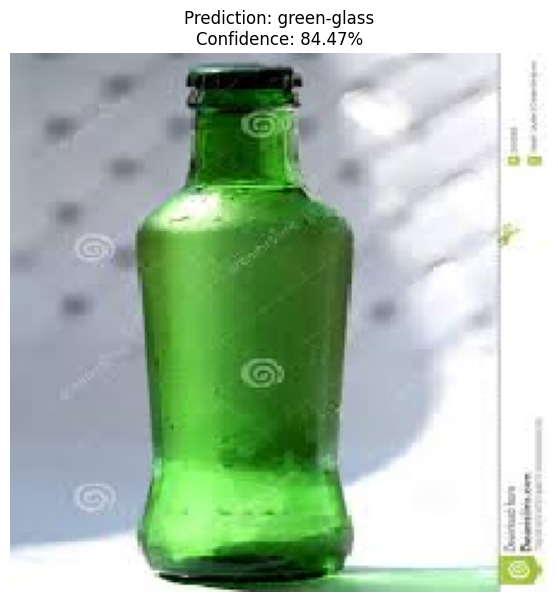

In [25]:
plt.figure(figsize=(7, 7))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

Now Grad-CAM

In [26]:
# ==========================================
# CREATE GRAD-CAM MODEL
# ==========================================

waste_last_conv_layer = waste_base_model.get_layer(
    "out_relu"
)

waste_gradcam_base = tf.keras.Model(
    inputs=waste_base_model.input,
    outputs=waste_last_conv_layer.output
)

print("Waste Grad-CAM model created!")
print(
    "Last convolutional layer:",
    waste_last_conv_layer.name
)

Waste Grad-CAM model created!
Last convolutional layer: out_relu


Step 25 — Get Classification Head

In [28]:
waste_gap_layer = waste_model.get_layer(
    "global_average_pooling2d"
)

waste_dense_layer = waste_model.get_layer(
    "dense"
)

waste_final_layer = waste_model.get_layer(
    "dense_1"
)

print("GAP layer   :", waste_gap_layer.name)
print("Dense layer :", waste_dense_layer.name)
print("Final layer :", waste_final_layer.name)

GAP layer   : global_average_pooling2d
Dense layer : dense
Final layer : dense_1


Step 26 — Create the Grad-CAM Function

In [29]:
def generate_waste_gradcam(img_batch, predicted_index):

    # Convert image to float32
    img_array = tf.cast(
        img_batch,
        tf.float32
    )

    # MobileNetV2 preprocessing
    img_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(
        img_array
    )

    with tf.GradientTape() as tape:

        # Get MobileNetV2 feature maps
        conv_outputs = waste_gradcam_base(
            img_preprocessed,
            training=False
        )

        # Watch feature maps
        tape.watch(conv_outputs)

        # Classification head
        x = waste_gap_layer(conv_outputs)

        x = waste_dense_layer(x)

        predictions = waste_final_layer(x)

        # Target class
        class_score = predictions[
            :,
            predicted_index
        ]

    # Calculate gradients
    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    heatmap = heatmap / (
        tf.reduce_max(heatmap)
        + tf.keras.backend.epsilon()
    )

    return heatmap.numpy()

Step 27 — Generate Grad-CAM

In [30]:
heatmap = generate_waste_gradcam(
    img_batch,
    predicted_index
)

print("Grad-CAM generated successfully!")
print("Heatmap shape:", heatmap.shape)

Grad-CAM generated successfully!
Heatmap shape: (7, 7)


Step 28 — Display Heatmap

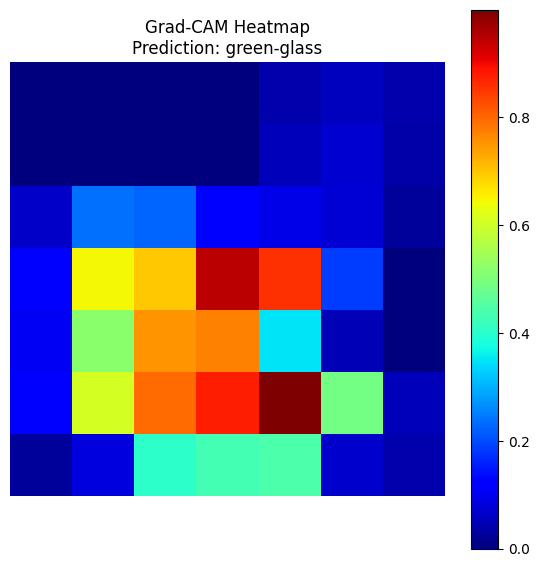

In [31]:
plt.figure(figsize=(7, 7))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.title(
    f"Grad-CAM Heatmap\n"
    f"Prediction: {predicted_class}"
)

plt.colorbar()
plt.axis("off")

plt.show()

Step 29 — Overlay Grad-CAM on Waste Image

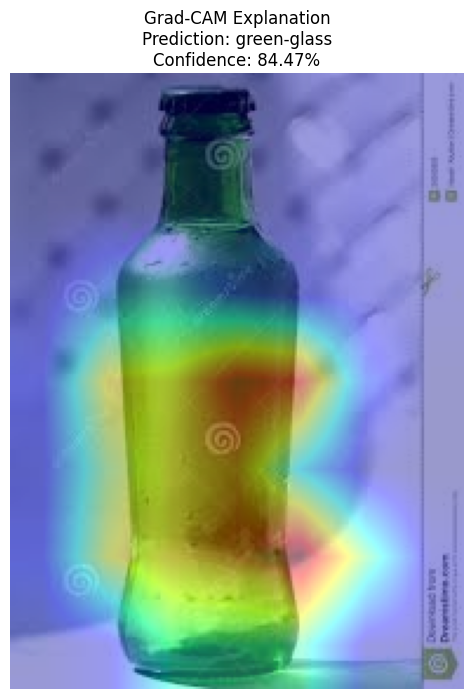

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Original image
original_waste = cv2.imread(
    waste_image_path
)

# BGR → RGB
original_waste = cv2.cvtColor(
    original_waste,
    cv2.COLOR_BGR2RGB
)

# Resize heatmap
heatmap_resized = cv2.resize(
    heatmap,
    (
        original_waste.shape[1],
        original_waste.shape[0]
    )
)

# Convert to 0-255
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

# Apply color map
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# BGR → RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay
superimposed_waste = cv2.addWeighted(
    original_waste,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Display
plt.figure(figsize=(8, 8))

plt.imshow(
    superimposed_waste
)

plt.title(
    f"Grad-CAM Explanation\n"
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()

Step 30 — Professional 3-Panel Visualization

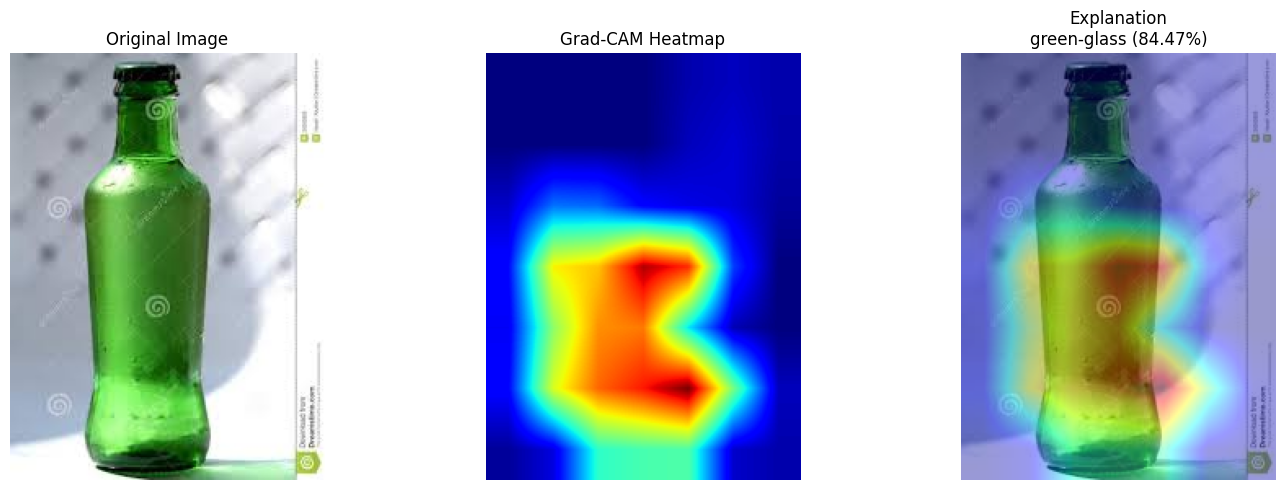

In [33]:
plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)

plt.imshow(
    original_waste
)

plt.title("Original Image")
plt.axis("off")


# Heatmap
plt.subplot(1, 3, 2)

plt.imshow(
    heatmap_resized,
    cmap="jet"
)

plt.title("Grad-CAM Heatmap")
plt.axis("off")


# Overlay
plt.subplot(1, 3, 3)

plt.imshow(
    superimposed_waste
)

plt.title(
    f"Explanation\n"
    f"{predicted_class} ({confidence:.2f}%)"
)

plt.axis("off")


plt.tight_layout()
plt.show()

Step 31— Install Flask and ngrok

In [34]:
!pip install -q flask pyngrok

Step 32 — Create Flask Application

In [35]:
from flask import Flask, request, render_template_string
import tensorflow as tf
import numpy as np
import os
import cv2
import base64

from PIL import Image
from io import BytesIO

app = Flask(__name__)

print("Flask application created successfully!")

Flask application created successfully!


Step 33 — Load the Saved Waste Model

In [37]:
WASTE_MODEL_PATH = (
    "/content/drive/MyDrive/"

    "smart_waste_mobilenetv2.keras"
)

waste_model = tf.keras.models.load_model(
    WASTE_MODEL_PATH
)

print("Waste model loaded successfully!")
print("Number of classes:", len(waste_class_names))

Waste model loaded successfully!
Number of classes: 12


Step 34 — Create the Web Interface

In [38]:
WASTE_HTML = """

<!DOCTYPE html>

<html>

<head>

    <title>Smart Waste Classification AI</title>

    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <style>

        body {
            font-family: Arial, sans-serif;
            background: #f4f7f6;
            margin: 0;
            padding: 30px;
            text-align: center;
        }

        .container {
            max-width: 950px;
            margin: auto;
            background: white;
            padding: 35px;
            border-radius: 18px;
            box-shadow: 0 5px 20px rgba(0,0,0,0.15);
        }

        h1 {
            color: #1565c0;
            margin-bottom: 10px;
        }

        .subtitle {
            color: #555;
            font-size: 18px;
            margin-bottom: 25px;
        }

        .upload-box {
            padding: 25px;
            border: 2px dashed #90caf9;
            border-radius: 12px;
            margin: 20px 0;
        }

        input[type="file"] {
            margin: 15px;
            font-size: 16px;
        }

        button {
            background: #1565c0;
            color: white;
            border: none;
            padding: 13px 30px;
            border-radius: 8px;
            font-size: 17px;
            cursor: pointer;
        }

        button:hover {
            background: #0d47a1;
        }

        .result {
            margin-top: 30px;
            padding: 25px;
            background: #e3f2fd;
            border-radius: 15px;
        }

        .prediction {
            font-size: 28px;
            font-weight: bold;
            color: #1565c0;
        }

        .confidence {
            font-size: 20px;
            margin: 15px;
        }

        .images {
            display: flex;
            flex-wrap: wrap;
            justify-content: center;
            gap: 25px;
            margin-top: 25px;
        }

        .image-box {
            width: 400px;
        }

        .image-box img {
            width: 100%;
            max-height: 400px;
            object-fit: contain;
            border-radius: 12px;
            border: 1px solid #ddd;
        }

        .image-box h3 {
            color: #333;
        }

        .footer {
            margin-top: 30px;
            color: #777;
            font-size: 14px;
        }

    </style>

</head>


<body>

<div class="container">

    <h1>♻️ Smart Waste Classification AI</h1>

    <p class="subtitle">
        Deep Learning + MobileNetV2 + Explainable AI
    </p>


    <form method="POST"
          enctype="multipart/form-data">

        <div class="upload-box">

            <h3>Upload a Waste Image</h3>

            <input
                type="file"
                name="image"
                accept="image/*"
                required
            >

            <br>

            <button type="submit">
                🔍 Classify Waste
            </button>

        </div>

    </form>


    {% if prediction %}

    <div class="result">

        <h2>Prediction Result</h2>

        <div class="prediction">
            {{ prediction }}
        </div>

        <div class="confidence">
            Confidence: <strong>{{ confidence }}%</strong>
        </div>


        <div class="images">

            <div class="image-box">

                <h3>Original Image</h3>

                <img src="data:image/jpeg;base64,
                {{ original_image }}">

            </div>


            <div class="image-box">

                <h3>Grad-CAM Explanation</h3>

                <img src="data:image/jpeg;base64,
                {{ gradcam }}">

            </div>

        </div>

    </div>

    {% endif %}


    <div class="footer">

        Powered by TensorFlow, MobileNetV2,
        Grad-CAM and Flask

    </div>

</div>

</body>

</html>

"""

Step 35 — Prediction Function

In [39]:
def predict_waste(image):

    # Resize
    image = image.resize(
        (224, 224)
    )

    # Convert to NumPy
    img_array = np.array(
        image
    )

    # Add batch dimension
    img_batch = np.expand_dims(
        img_array,
        axis=0
    )

    # Prediction
    predictions = waste_model.predict(
        img_batch,
        verbose=0
    )

    # Highest probability class
    predicted_index = np.argmax(
        predictions[0]
    )

    predicted_class = waste_class_names[
        predicted_index
    ]

    confidence = (
        predictions[0][predicted_index]
        * 100
    )

    return (
        predicted_index,
        predicted_class,
        confidence,
        img_batch
    )


print("Prediction function created!")

Prediction function created!


Step 36 — Grad-CAM Function for Flask

We'll reuse the exact Grad-CAM approach that worked successfully.

In [40]:
def flask_waste_gradcam(
    img_batch,
    predicted_index
):

    img_array = tf.cast(
        img_batch,
        tf.float32
    )

    # MobileNetV2 preprocessing
    img_preprocessed = (
        tf.keras.applications
        .mobilenet_v2
        .preprocess_input(
            img_array
        )
    )

    with tf.GradientTape() as tape:

        # MobileNetV2 feature maps
        conv_outputs = waste_gradcam_base(
            img_preprocessed,
            training=False
        )

        tape.watch(
            conv_outputs
        )

        # Classification head
        x = waste_gap_layer(
            conv_outputs
        )

        x = waste_dense_layer(x)

        predictions = waste_final_layer(
            x
        )

        class_score = predictions[
            :,
            predicted_index
        ]

    # Gradients
    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weighted feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    heatmap = heatmap / (
        tf.reduce_max(heatmap)
        + tf.keras.backend.epsilon()
    )

    return heatmap.numpy()


print("Flask Grad-CAM function created!")

Flask Grad-CAM function created!


Step 37 — Convert Images to Base64

The browser needs an image format it can display directly.

In [41]:
def image_to_base64(image_array):

    # Convert NumPy → PIL
    image = Image.fromarray(
        image_array.astype(np.uint8)
    )

    buffer = BytesIO()

    image.save(
        buffer,
        format="JPEG"
    )

    encoded = base64.b64encode(
        buffer.getvalue()
    ).decode("utf-8")

    return encoded

Now create the Grad-CAM overlay:

In [42]:
def create_waste_gradcam_image(
    img_batch,
    heatmap
):

    # Original image
    original = img_batch[0].astype(
        np.uint8
    )

    # Resize heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224)
    )

    # Convert to 0-255
    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    # Apply color map
    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    # BGR → RGB
    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Overlay
    overlay = cv2.addWeighted(
        original,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    return image_to_base64(
        overlay
    )

Step 38 — Create Flask Route

This is where everything connects.

In [43]:
@app.route(
    "/",
    methods=["GET", "POST"]
)

def waste_home():

    prediction = None
    confidence = None
    gradcam_image = None
    original_image = None

    if request.method == "POST":

        file = request.files.get(
            "image"
        )

        if file:

            image = Image.open(
                file
            ).convert("RGB")

            # Prediction
            (
                predicted_index,
                prediction,
                confidence,
                img_batch
            ) = predict_waste(
                image
            )

            # Grad-CAM
            heatmap = flask_waste_gradcam(
                img_batch,
                predicted_index
            )

            # Create Grad-CAM image
            gradcam_image = (
                create_waste_gradcam_image(
                    img_batch,
                    heatmap
                )
            )

            # Original image
            original_image = image_to_base64(
                img_batch[0]
            )

            confidence = round(
                confidence,
                2
            )

    return render_template_string(
        WASTE_HTML,
        prediction=prediction,
        confidence=confidence,
        gradcam=gradcam_image,
        original_image=original_image
    )

Step 39 — Start Flask

We'll use port 5001 for Project 2. This avoids a conflict if your Project 1 Flask server is still running.

In [44]:
import threading

def run_waste_flask():

    app.run(
        host="0.0.0.0",
        port=5001,
        debug=False,
        use_reloader=False
    )


waste_flask_thread = threading.Thread(
    target=run_waste_flask
)

waste_flask_thread.daemon = True

waste_flask_thread.start()

print("====================================")
print("♻️ Smart Waste Flask Server Started")
print("====================================")
print("Local Port: 5001")

♻️ Smart Waste Flask Server Started
Local Port: 5001


Step 40 — Configure ngrok Token

If you haven't already configured the token in this new notebook, run:

In [45]:
from getpass import getpass
import os

NGROK_AUTHTOKEN = getpass(
    "Enter your ngrok authtoken: "
)

os.environ[
    "NGROK_AUTHTOKEN"
] = NGROK_AUTHTOKEN

print("ngrok token configured.")

Enter your ngrok authtoken: ··········
ngrok token configured.


Step 41 — Create Public URL 🌍

In [46]:
from pyngrok import ngrok

# Close old tunnels
ngrok.kill()

# Create tunnel
public_url = ngrok.connect(
    5001,
    "http"
)

print("============================================")
print("🌍 SMART WASTE AI - PUBLIC URL")
print("============================================")
print(public_url)

🌍 SMART WASTE AI - PUBLIC URL
NgrokTunnel: "https://snarlingly-uncasked-vergie.ngrok-free.dev" -> "http://localhost:5001"
